# **AED and Model Analysis**

In [ ]:
import pandas as pd
import numpy as np
import os

# Create directories if they don't exist
os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

# Load the sample dataset
df = pd.read_csv('evaluation_sample_n500.csv')

# DoR columns (Depth of Reasoning)
dor_columns = [
    'gr_dor_claude_35_haiku',
    'gr_dor_ds_v3',
    'gr_dor_gpt_41_nano',
    'gr_dor_gpt_4o_mini',
    'gr_dor_grok_3_mini_beta'
]

# ORI columns (not used in this block)
ori_columns = [
    'gr_ori_claude_35_haiku',
    'gr_ori_ds_v3',
    'gr_ori_gpt_41_nano',
    'gr_ori_gpt_4o_mini',
    'gr_ori_grok_3_mini_beta'
]

gr_dor_columns = [c for c in df.columns if c.startswith('gr_dor_')]
gr_ori_columns = [c for c in df.columns if c.startswith('gr_ori_')]

print("=" * 80)
print("ANALYSIS: Proportion of RECORDS with Compressed Reasoning (hit=1 & DoR < 4)")
print("=" * 80)

# Calculate per RECORD (not per prediction)
dor_matrix = df[dor_columns].values
hit_array = df['hit'].values

# Records where at least 1 model has DoR < 4 AND hit = 1
has_compressed_reasoning = (np.sum(dor_matrix < 4, axis=1) > 0) & (hit_array == 1)
compressed_records = has_compressed_reasoning.sum()

# Total records with hit = 1
hit_records = (hit_array == 1).sum()

# Proportion
proportion = (compressed_records / hit_records) * 100 if hit_records > 0 else 0

print(f"\nTotal records: {len(df)}")
print(f"Records with hit=1: {hit_records}")
print(f"Records with compressed reasoning (hit=1 & ≥1 model with DoR<4): {compressed_records}")
print(f"\nPROPORTION: {proportion:.1f}%")

ANALYSIS: Proportion of RECORDS with Compressed Reasoning (hit=1 & DoR < 4)

Total records: 500
Records with hit=1: 412
Records with compressed reasoning (hit=1 & ≥1 model with DoR<4): 78

PROPORTION: 18.9%


Calculated median Depth of Reasoning (gr_dor_median) from individual models
Calculated median Originality (gr_ori_median) from individual models


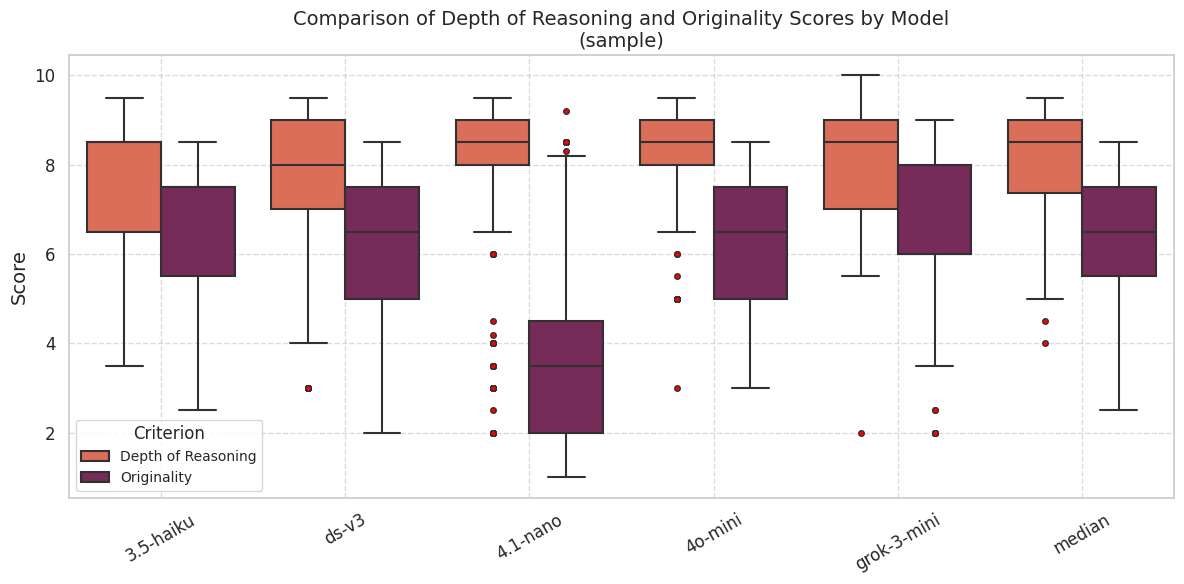

,Criterion,Model,Mean,Std,Median,Min,Max,Coefficient of Variation
0,Depth of Reasoning,3.5-haiku,7.7122,1.436467,8.5,3.5,9.5,0.186259
1,Depth of Reasoning,ds-v3,7.5020,1.886561,8.0,3.0,9.5,0.251474
2,Depth of Reasoning,4.1-nano,7.9824,1.823848,8.5,2.0,9.5,0.228484
3,Depth of Reasoning,4o-mini,8.3250,0.901388,8.5,3.0,9.5,0.108275
4,Depth of Reasoning,grok-3-mini,8.0690,1.356990,8.5,2.0,10.0,0.168173
5,Depth of Reasoning,Median across models,7.9694,1.186195,8.5,4.0,9.5,0.148844
6,Originality,3.5-haiku,6.6672,1.511176,7.5,2.5,8.5,0.226658
7,Originality,ds-v3,5.9250,1.668966,6.5,2.0,8.5,0.281682
8,Originality,4.1-nano,3.9024,2.105255,3.5,1.0,9.2,0.539477
9,Originality,4o-mini,6.4140,1.125672,6.5,3.0,8.5,0.175502


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Configuration ===
model_name_map = {
    "gpt_4o_mini":    "4o-mini",
    "gpt_41_nano":    "4.1-nano",
    "claude_35_haiku": "3.5-haiku",
    "grok_3_mini_beta": "grok-3-mini",
    "ds_v3":          "ds-v3"
}

# === Calculate median columns if they don't exist ===
if 'gr_dor_median' not in df.columns:
    df['gr_dor_median'] = df[gr_dor_columns].median(axis=1)
    print("Calculated median Depth of Reasoning (gr_dor_median) from individual models")

if 'gr_ori_median' not in df.columns:
    df['gr_ori_median'] = df[gr_ori_columns].median(axis=1)
    print("Calculated median Originality (gr_ori_median) from individual models")

# === Prepare data for Depth of Reasoning (DoR) boxplot ===
df_box_dor = df[list(gr_dor_columns) + ['gr_dor_median']].copy()
df_box_dor.columns = [col.replace('gr_dor_', '') for col in df_box_dor.columns]
df_box_dor.rename(columns={k: model_name_map.get(k, k) for k in df_box_dor.columns}, inplace=True)

df_long_dor = df_box_dor.melt(var_name='Model', value_name='Score')
df_long_dor['Criterion'] = 'Depth of Reasoning'

# === Prepare data for Originality boxplot ===
df_box_ori = df[list(gr_ori_columns) + ['gr_ori_median']].copy()
df_box_ori.columns = [col.replace('gr_ori_', '') for col in df_box_ori.columns]
df_box_ori.rename(columns={k: model_name_map.get(k, k) for k in df_box_ori.columns}, inplace=True)

df_long_ori = df_box_ori.melt(var_name='Model', value_name='Score')
df_long_ori['Criterion'] = 'Originality'

# === Combine both criteria into one long-format DataFrame ===
df_long_combined = pd.concat([df_long_dor, df_long_ori], ignore_index=True)

# === Create a single grouped boxplot ===
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

boxplot = sns.boxplot(
    data=df_long_combined,
    x='Model',
    y='Score',
    hue='Criterion',
    palette='rocket_r',
    linewidth=1.5,
    fliersize=5,
    dodge=True,
    flierprops=dict(marker='o', markerfacecolor='red', markersize=4)
)

plt.title('Comparison of Depth of Reasoning and Originality Scores by Model\n(sample)', fontsize=14)
plt.xlabel('')
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=30, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Criterion', loc='lower left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('figures/comparison_depth_of_reasoning_and_originality_scores_sample.png', dpi=360)
plt.show()
plt.close()

# === Summary statistics function ===
def compute_summary(columns, prefix, alias_map, metric_label):
    rows = []
    for col in columns:
        raw_name = col.replace(prefix, '')
        name = alias_map.get(raw_name, raw_name)
        data = df[col]
        rows.append({
            'Criterion': metric_label,
            'Model': name,
            'Mean': data.mean(),
            'Std': data.std(),
            'Median': data.median(),
            'Min': data.min(),
            'Max': data.max(),
            'Coefficient of Variation': data.std() / data.mean() if data.mean() != 0 else None
        })
    
    # Add row for the median-across-models
    median_col = f'{prefix}median'
    if median_col in df.columns:
        rows.append({
            'Criterion': metric_label,
            'Model': 'Median across models',
            'Mean': df[median_col].mean(),
            'Std': df[median_col].std(),
            'Median': df[median_col].median(),
            'Min': df[median_col].min(),
            'Max': df[median_col].max(),
            'Coefficient of Variation': df[median_col].std() / df[median_col].mean() if df[median_col].mean() != 0 else None
        })
    
    return pd.DataFrame(rows)


# Compute statistics for both metrics
stats_dor = compute_summary(gr_dor_columns, 'gr_dor_', model_name_map, 'Depth of Reasoning')
stats_ori = compute_summary(gr_ori_columns, 'gr_ori_', model_name_map, 'Originality')

# Combine and save
summary_stats = pd.concat([stats_dor, stats_ori], ignore_index=True)
summary_stats.to_csv('data/summary_statistics_sample.csv', index=False)

# Display the table
display(summary_stats)

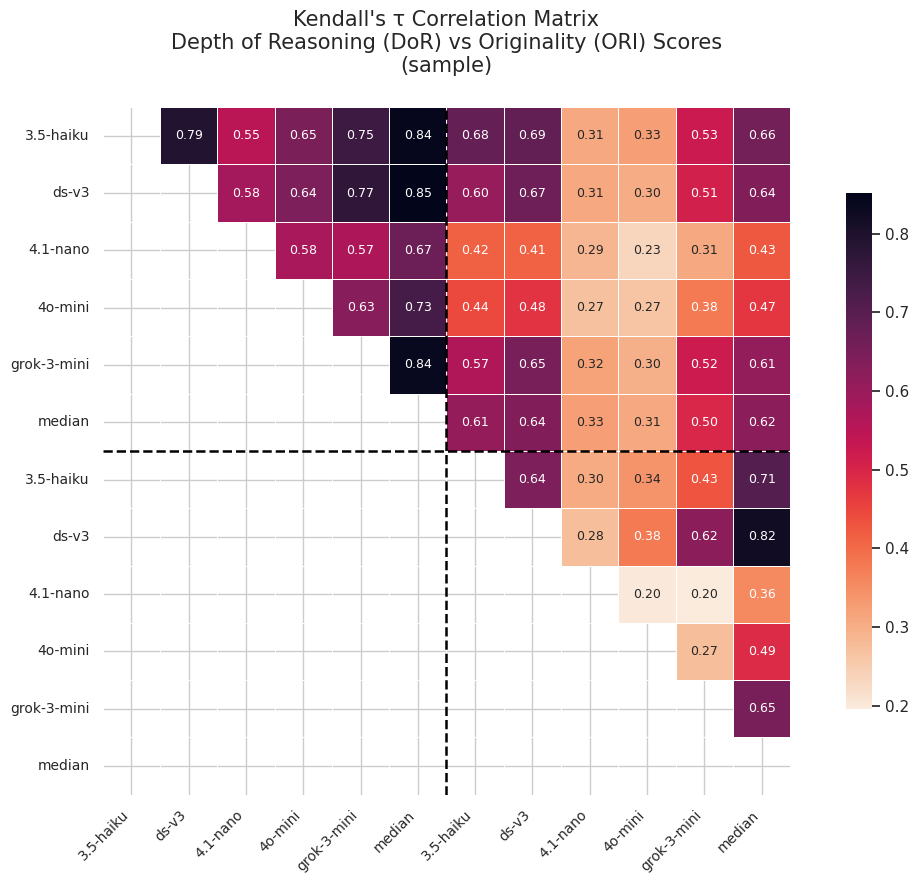

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Alias mapping for cleaner display names
model_name_map = {
    "gpt_4o_mini":     "4o-mini",
    "gpt_41_nano":     "4.1-nano",
    "claude_35_haiku": "3.5-haiku",
    "grok_3_mini_beta": "grok-3-mini",
    "ds_v3":           "ds-v3"
}

# Prepare data for correlation 
# Combine all DoR columns + median + all ORI columns + median
df_for_correlation = pd.concat(
    [df[gr_dor_columns], df[['gr_dor_median']],
     df[gr_ori_columns], df[['gr_ori_median']]],
    axis=1
)

# Compute Kendall's tau correlation matrix
corr_matrix = df_for_correlation.corr(method='kendall')

# Clean column names for visualization 
def clean_label(label):
    # Replace model codes with short names
    for key, short in model_name_map.items():
        if key in label:
            label = label.replace(key, short)
    # Remove prefixes and improve readability
    label = label.replace('gr_dor_', '')\
                 .replace('gr_ori_', '')\
                 .replace('_median', ' (median)')
    return label

# Apply clean names to both index and columns
clean_names = [clean_label(col) for col in df_for_correlation.columns]
corr_matrix.index = clean_names
corr_matrix.columns = clean_names

# Create mask for lower triangle (to show only upper part) 
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap 
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='rocket_r',
    square=True,
    cbar_kws={"shrink": 0.75},
    linewidths=0.6,
    mask=mask,
    annot_kws={"size": 9}
)

# Add separation line between DoR and ORI blocks 
# Position: after the last DoR column + median column
dor_block_end = len(gr_dor_columns) + 1   # +1 for the median column

plt.axhline(y=dor_block_end, color='black', linewidth=1.8, linestyle='--')
plt.axvline(x=dor_block_end, color='black', linewidth=1.8, linestyle='--')

# Aesthetics & labels 
plt.title(
    "Kendall's τ Correlation Matrix\n"
    "Depth of Reasoning (DoR) vs Originality (ORI) Scores\n"
    "(sample)",
    fontsize=15,
    pad=25
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('figures/kendall_tau_correlation_matrix_sample.png', dpi=360, bbox_inches='tight')
plt.show()

# Adversarial Compensation Effect (ACE) Analysis

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau
from sklearn.metrics import f1_score

# Set seed for reproducibility
np.random.seed(42)

# Model display name mapping
model_name_map = {
    "gpt_4o_mini":     "4o-mini",
    "gpt_41_nano":     "4.1-nano",
    "claude_35_haiku": "3.5-haiku",
    "grok_3_mini_beta": "grok-3-mini",
    "ds_v3":           "ds-v3"
}

# Prompt variants being compared
prompt_types = ['naive', 'cot', 'adversarial']

# List of model identifiers (keys from the map)
model_list = list(model_name_map.keys())

summary_data = []

for model_key in model_list:
    # Find the actual model name in the DataFrame that contains this substring
    model_match = next((m for m in df['model'].unique() if model_key in m), None)
    
    if model_match is None:
        print(f"[!] Warning: No matching model found for identifier '{model_key}'")
        continue
    
    try:
        # Find the corresponding DoR and ORI columns
        dor_col = next(c for c in df.columns if f"gr_dor_{model_key}" in c)
        ori_col = next(c for c in df.columns if f"gr_ori_{model_key}" in c)
    except StopIteration:
        print(f"[!] Warning: Could not find DoR/ORI columns for model '{model_key}'")
        continue
    
    # Filter data for this specific model
    df_model = df[df["model"] == model_match].copy()
    
    wf1_means = []
    dor_means = []
    dor_vars  = []
    ori_means = []
    ori_vars  = []
    kendall_dor_taus = []
    kendall_ori_taus = []
    
    for prompt in prompt_types:
        subset = df_model[df_model["prompt_type"] == prompt]
        
        # Weighted F1 Score (WF₁) 
        if subset.empty:
            wf1 = 0.0
        else:
            y_true = subset["answer"]
            y_pred = subset["model_answer"]
            
            # Clean and align valid pairs
            mask = y_true.notna() & y_pred.notna()
            y_true = y_true[mask].astype(str).str.strip().str.upper()
            y_pred = y_pred[mask].astype(str).str.strip().str.upper()
            
            if len(y_true) == 0:
                wf1 = 0.0
            else:
                # Get all unique labels from both true and predicted
                labels = sorted(set(y_true.unique()) | set(y_pred.unique()))
                wf1 = f1_score(
                    y_true, y_pred,
                    labels=labels,
                    average="weighted",
                    zero_division=0
                )
        wf1_means.append(wf1)
        
        # Normalized DoR and ORI 
        dor_values = subset[dor_col]
        ori_values = subset[ori_col]
        
        # Min-max normalization (handle constant case)
        if dor_values.max() != dor_values.min():
            dor_norm = (dor_values - dor_values.min()) / (dor_values.max() - dor_values.min())
        else:
            dor_norm = dor_values * 0  # or pd.Series(0, index=dor_values.index)
        
        if ori_values.max() != ori_values.min():
            ori_norm = (ori_values - ori_values.min()) / (ori_values.max() - ori_values.min())
        else:
            ori_norm = ori_values * 0
        
        dor_means.append(dor_norm.mean() if not subset.empty else 0.0)
        dor_vars.append (dor_norm.var()  if not subset.empty else 0.0)
        ori_means.append(ori_norm.mean() if not subset.empty else 0.0)
        ori_vars.append (ori_norm.var()  if not subset.empty else 0.0)
        
        # Kendall's τ with correctness (hit) 
        if len(subset) > 1 and dor_norm.nunique() > 1:
            tau_dor, _ = kendalltau(dor_norm, subset["hit"])
        else:
            tau_dor = 0.0
        kendall_dor_taus.append(tau_dor)
        
        if len(subset) > 1 and ori_norm.nunique() > 1:
            tau_ori, _ = kendalltau(ori_norm, subset["hit"])
        else:
            tau_ori = 0.0
        kendall_ori_taus.append(tau_ori)
    
    # Store results for this model 
    model_display_name = model_name_map[model_key]
    
    for prompt, wf1, d_mean, d_var, o_mean, o_var, t_dor, t_ori in zip(
        prompt_types, wf1_means, dor_means, dor_vars, ori_means, ori_vars,
        kendall_dor_taus, kendall_ori_taus
    ):
        summary_data.append({
            'Model':          model_display_name,
            'Prompt Type':    prompt.capitalize(),   # nicer display: Naive → naive → Naive
            'Weighted F1':    wf1,
            'Mean DoR (norm)':   round(d_mean, 4),
            'DoR Variance (norm)': round(d_var, 4),
            'Mean Originality (norm)': round(o_mean, 4),
            'Originality Variance (norm)': round(o_var, 4),
            "Kendall's τ (DoR vs hit)":  round(t_dor, 4),
            "Kendall's τ (ORI vs hit)":  round(t_ori, 4)
        })

# Create and display summary table 
summary_df = pd.DataFrame(summary_data)

# Optional: nicer column order and formatting
summary_df = summary_df[[
    'Model', 'Prompt Type',
    'Weighted F1',
    'Mean DoR (norm)', 'DoR Variance (norm)',
    'Mean Originality (norm)', 'Originality Variance (norm)',
    "Kendall's τ (DoR vs hit)", "Kendall's τ (ORI vs hit)"
]]

display(summary_df.round(4))

,Model,Prompt Type,Weighted F1,Mean DoR (norm),DoR Variance (norm),Mean Originality (norm),Originality Variance (norm),Kendall's τ (DoR vs hit),Kendall's τ (ORI vs hit)
0,4o-mini,Naive,0.6820,0.6772,0.1218,0.4383,0.1478,0.7706,0.0000
1,4o-mini,Cot,0.7896,0.6645,0.0415,0.4737,0.0740,0.4622,-0.0081
2,4o-mini,Adversarial,0.7401,0.6019,0.0433,0.5079,0.0938,0.3154,0.0274
3,4.1-nano,Naive,0.9360,0.6226,0.1243,0.1784,0.0515,0.0942,-0.0599
4,4.1-nano,Cot,0.8864,0.8693,0.0506,0.4321,0.1282,-0.0744,0.2712
5,4.1-nano,Adversarial,0.8320,0.8489,0.0484,0.4177,0.0901,0.3414,0.2247
6,3.5-haiku,Naive,0.9024,0.6179,0.0587,0.7683,0.0825,0.0472,0.1387
7,3.5-haiku,Cot,0.7649,0.7080,0.0767,0.6827,0.0578,0.4233,0.0444
8,3.5-haiku,Adversarial,0.7367,0.6696,0.0812,0.7927,0.0713,0.3278,-0.1847
9,grok-3-mini,Naive,0.9060,0.3209,0.0669,0.6047,0.0465,0.1458,0.0801


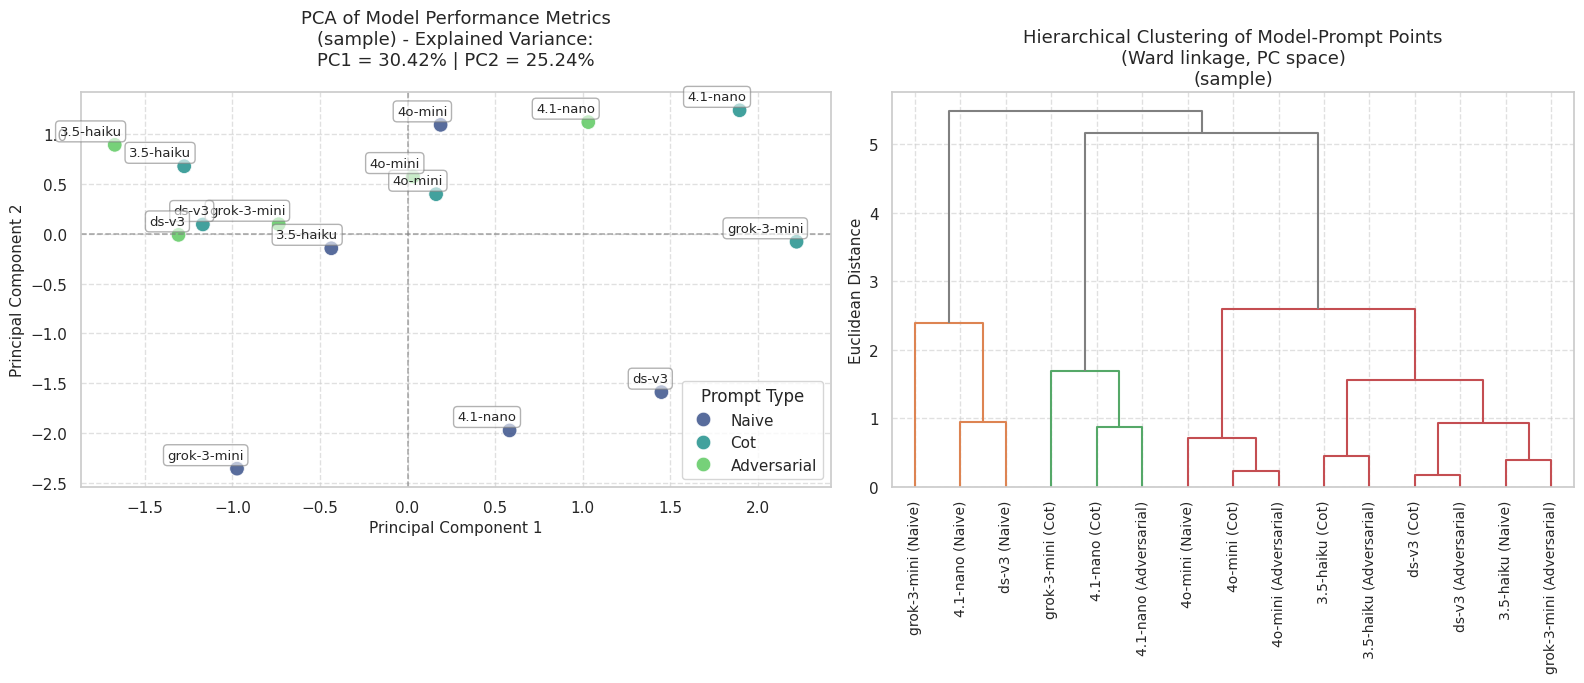


Model Instability Index (average pairwise distance in PCA space):


,Model,Instability Index
0,grok-3-mini,1.0382
1,4.1-nano,0.8283
2,ds-v3,0.7179
3,3.5-haiku,0.3599
4,4o-mini,0.1618


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from itertools import combinations

# Prepare features for PCA 
features = [
    'Weighted F1',
    'Mean DoR (norm)',
    'DoR Variance (norm)',
    'Mean Originality (norm)',
    'Originality Variance (norm)'
]

# Extract the feature matrix
X = summary_df[features].copy()

# Standardize (zero mean, unit variance)
X_scaled = (X - X.mean()) / X.std()

# Perform PCA (2 components) 
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Create PCA results DataFrame
pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PC1', 'PC2']
)
pca_df['Model']       = summary_df['Model']
pca_df['Prompt Type'] = summary_df['Prompt Type']

# Calculate "instability" (average pairwise Euclidean distance in PC space) 
instability_scores = []

for model in pca_df['Model'].unique():
    points = pca_df[pca_df['Model'] == model][['PC1', 'PC2']].values
    
    if len(points) <= 1:
        instab_index = 0.0
    else:
        dists = []
        for (i, j) in combinations(range(len(points)), 2):
            dists.append(np.linalg.norm(points[i] - points[j]))
        
        # Mean pairwise distance (normalized by number of pairs)
        n_pairs = len(points) * (len(points) - 1) / 2
        instab_index = np.mean(dists) / n_pairs if n_pairs > 0 else 0.0
    
    instability_scores.append({
        'Model': model,
        'Instability Index': instab_index
    })

# Visualization 
# Color palette for prompt types
palette = sns.color_palette("viridis", len(pca_df['Prompt Type'].unique()))

# Create side-by-side figure: PCA scatter + Dendrogram
fig, axs = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1.1, 1]})

# Left: PCA Scatter Plot 
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Prompt Type',
    palette=palette,
    alpha=0.85,
    s=110,
    edgecolor='white',
    linewidth=0.6,
    ax=axs[0]
)

# Quadrant lines
axs[0].axhline(0, color='gray', linestyle='--', linewidth=1.1, alpha=0.7)
axs[0].axvline(0, color='gray', linestyle='--', linewidth=1.1, alpha=0.7)

# Annotate each point with model name
for i, model in enumerate(pca_df['Model']):
    x_val = pca_df['PC1'].iloc[i]
    y_val = pca_df['PC2'].iloc[i]
    axs[0].annotate(
        model,
        (x_val, y_val),
        fontsize=9.5,
        ha='right',
        va='bottom',
        xytext=(5, 5),
        textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.6)
    )

# Title with explained variance
evr = pca.explained_variance_ratio_
axs[0].set_title(
    f'PCA of Model Performance Metrics\n'
    f'(sample) - Explained Variance:\n'
    f'PC1 = {evr[0]:.2%} | PC2 = {evr[1]:.2%}',
    fontsize=13,
    pad=20
)

axs[0].set_xlabel('Principal Component 1', fontsize=11)
axs[0].set_ylabel('Principal Component 2', fontsize=11)
axs[0].grid(True, linestyle='--', alpha=0.6)

# Right: Hierarchical Clustering Dendrogram 
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(pca_df[['PC1', 'PC2']], method='ward')

labels = [f"{m} ({p})" for m, p in zip(pca_df['Model'], pca_df['Prompt Type'])]

dendrogram(
    Z,
    labels=labels,
    leaf_rotation=90,
    leaf_font_size=10,
    ax=axs[1],
    above_threshold_color='gray'
)

axs[1].set_title('Hierarchical Clustering of Model-Prompt Points\n(Ward linkage, PC space)\n(sample)', fontsize=13)
axs[1].set_ylabel('Euclidean Distance', fontsize=11)
axs[1].set_xlabel('')
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('figures/pca_and_dendrogram_sample.png', dpi=360, bbox_inches='tight')
plt.show()

# Display instability ranking 
instability_df = pd.DataFrame(instability_scores)
instability_df = instability_df.sort_values(by='Instability Index', ascending=False)\
                               .reset_index(drop=True)

print("\nModel Instability Index (average pairwise distance in PCA space):")
display(instability_df.round(4))

# Effect Size Analysis

In [6]:
from scipy import stats
import numpy as np

def calculate_effect_size(df_input, score_columns):
    """
    Calculate Cohen's d (absolute) and convert it to point-biserial correlation r
    for each score column, comparing 'hit=1' vs 'hit=0' groups.
    """
    effect_sizes = {}
    
    for col in score_columns:
        hit_scores   = df_input[df_input['hit'] == 1][col]
        miss_scores  = df_input[df_input['hit'] == 0][col]
        
        # Skip if either group is empty
        if len(hit_scores) == 0 or len(miss_scores) == 0:
            effect_sizes[col] = np.nan
            continue
        
        # Cohen's d (using pooled standard deviation)
        mean_diff = hit_scores.mean() - miss_scores.mean()
        pooled_std = np.sqrt((hit_scores.std()**2 + miss_scores.std()**2) / 2)
        
        if pooled_std == 0:
            d = 0.0
        else:
            d = np.abs(mean_diff) / pooled_std
        
        # Convert Cohen's d to point-biserial r (common approximation)
        r = d / np.sqrt(d**2 + 4)
        
        effect_sizes[col] = r
    
    return effect_sizes


# Identify relevant DoR and ORI columns 
# We exclude any aggregate columns (median, mean, std)
dor_cols = [
    col for col in df.columns
    if col.startswith('gr_dor_')
    and not col.endswith('median')
    and not col.endswith('mean')
    and not col.endswith('std')
]

ori_cols = [
    col for col in df.columns
    if col.startswith('gr_ori_')
    and not col.endswith('median')
    and not col.endswith('mean')
    and not col.endswith('std')
]

score_columns = dor_cols + ori_cols

# Compute effect sizes 
effect_sizes = calculate_effect_size(df, score_columns)

# Display results 
print("=" * 70)
print("Point-biserial Correlation (r) - Effect Size between Correct (hit=1) and Incorrect (hit=0)")
print("for Depth of Reasoning (DoR) and Originality (ORI) scores")
print("=" * 70)

if not effect_sizes:
    print("No valid score columns found or groups are empty.")
else:
    # Sort by absolute effect size (descending) for easier interpretation
    sorted_effects = sorted(effect_sizes.items(), key=lambda x: abs(x[1]), reverse=True)
    
    for col, r_value in sorted_effects:
        # Clean column name for display
        clean_name = col.replace('gr_dor_', 'DoR - ').replace('gr_ori_', 'ORI - ')
        print(f"{clean_name: <35} : {r_value:>8.4f}")
    
    print("\nInterpretation guide:")
    print("  |r| < 0.10 : very small / negligible")
    print("  |r| 0.10–0.30 : small")
    print("  |r| 0.30–0.50 : moderate")
    print("  |r| > 0.50     : large")

Point-biserial Correlation (r) - Effect Size between Correct (hit=1) and Incorrect (hit=0)
for Depth of Reasoning (DoR) and Originality (ORI) scores
DoR - gpt_4o_mini                   :   0.4125
ORI - ds_v3                         :   0.2331
DoR - gpt_41_nano                   :   0.2187
ORI - claude_35_haiku               :   0.1814
ORI - grok_3_mini_beta              :   0.1702
DoR - ds_v3                         :   0.0443
ORI - gpt_41_nano                   :   0.0370
DoR - grok_3_mini_beta              :   0.0271
ORI - gpt_4o_mini                   :   0.0251
DoR - claude_35_haiku               :   0.0169

Interpretation guide:
  |r| < 0.10 : very small / negligible
  |r| 0.10–0.30 : small
  |r| 0.30–0.50 : moderate
  |r| > 0.50     : large
